# Week 3 Assignment: Healthcare Adverse Drug Reactions (ADR) ML Pipeline

This notebook implements a complete Machine Learning pipeline to analyze and predict the severity of **Adverse Drug Reactions (ADR)** using patient demographic, drug dosage, and reporting country data fetched from the **openFDA** adverse events API.

### Objective:
Build a decision tree classification model to classify ADR severity (Serious vs. Non-Serious) and understand the key factors driving high-severity clinical outcomes.


## Part 1: Problem Understanding

#### 1. What are ADRs?
Adverse Drug Reactions (ADRs) are unwanted, harmful, or unintended side effects that occur when a patient takes a medication at normal, recommended doses. Unlike accidental overdoses, ADRs happen during standard medical use.

#### 2. Why is ADR prediction important?
Predicting ADRs is extremely important in healthcare because it helps doctors and pharmacists identify patients who might be at high risk before they start a drug. This can prevent serious complications, reduce hospital stays, lower healthcare costs, and ultimately save lives.

#### 3. Why is this a classification problem?
This is a classification problem because the goal is to predict a categorical label (specifically, whether an adverse reaction is 'Serious' or 'Non-Serious'). We aren't predicting a continuous numerical value (like blood pressure or drug dosage), but rather assigning reports to predefined groups.

#### 4. Binary vs Multi-class classification.
Binary classification involves predicting one of two possible outcomes (e.g., Serious vs Non-Serious, or Yes vs No). Multi-class classification involves predicting one of three or more categories (e.g., predicting if a reaction is Mild, Moderate, or Severe).

#### 5. Why are Decision Trees suitable?
Decision Trees are highly suitable for healthcare because they are highly interpretable. Doctors can easily follow the tree's logical path of 'if-else' rules (like 'if age > 65 and drug is injection, then risk is high') to understand why a prediction was made. They also handle a mix of categorical and numerical variables without requiring complex data scaling.


## Part 2: Data Exploration

We will load the fetched adverse drug reaction dataset and display its basic structure, shapes, datatypes, and summary statistics.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data_path = "P:/AIML_IMMERSION_ASSIGNMENT/WEEK_3/openfda_adr_dataset.csv"
df = pd.read_csv(data_path)

# Display first 10 rows
print("First 10 rows of the dataset:")
print(df.head(10))

# Display shape
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Display data types and info
print("\nDataset Info:")
print(df.info())

# Display missing values count
print("\nMissing Values Count per Column:")
print(df.isnull().sum())

# Display summary statistics
print("\nSummary Statistics of Numerical Columns:")
print(df.describe())

# Display unique values count
print("\nUnique Values per Column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")


First 10 rows of the dataset:
    age  gender  adr_severity  ... country hospitalization  death
0  26.0     1.0             1  ...     NaN               0      1
1  77.0     2.0             1  ...     NaN               0      0
2   NaN     2.0             1  ...     NaN               0      0
3   NaN     1.0             2  ...      US               0      0
4   NaN     2.0             2  ...      US               0      0
5  48.0     2.0             2  ...      US               0      0
6  68.0     2.0             2  ...      US               0      0
7  65.0     2.0             2  ...      US               0      0
8  59.0     2.0             2  ...      US               0      0
9  42.0     1.0             2  ...      US               0      0

[10 rows x 7 columns]

Dataset Shape: 2000 rows, 7 columns

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            ----

## Part 3: Data Cleaning

We will clean the dataset by handling missing values, standardizing raw drug dosage form names, mapping categorical codes to readable text labels, creating age groups, and preparing binary features.


In [ ]:
# Copy dataframe for cleaning
df_clean = df.copy()

# 1. Handle missing values
# Impute age with median
age_median = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(age_median)

# Impute gender (0 is unknown, NaN mapped to 0)
df_clean['gender'] = df_clean['gender'].fillna(0).astype(int).astype(str)

# Impute country and dosage form with 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['drug_dosage_form'] = df_clean['drug_dosage_form'].fillna('Unknown')

# 2. Map codes to readable strings for visualization
gender_map = {'1': 'Male', '2': 'Female', '0': 'Unknown'}
df_clean['gender_name'] = df_clean['gender'].map(gender_map)

# Target: 1 = Serious, 2 = Non-Serious
severity_map = {1: 'Serious', 2: 'Non-Serious'}
df_clean['severity_name'] = df_clean['adr_severity'].map(severity_map)

# 3. Standardize drug dosage forms
def standardize_dosage(form):
    form_lower = str(form).lower()
    if 'tablet' in form_lower:
        return 'Tablet'
    elif 'capsule' in form_lower:
        return 'Capsule'
    elif 'injection' in form_lower or 'inj' in form_lower:
        return 'Injection'
    elif 'solution' in form_lower or 'liquid' in form_lower:
        return 'Oral Solution'
    elif 'suspension' in form_lower:
        return 'Suspension'
    elif 'unknown' in form_lower:
        return 'Unknown'
    else:
        return 'Other'

df_clean['dosage_form_clean'] = df_clean['drug_dosage_form'].apply(standardize_dosage)

# 4. Standardize countries (show top 5, group rest as 'Other')
top_countries = df_clean['country'].value_counts().index[:5]
df_clean['country_clean'] = df_clean['country'].apply(lambda x: x if x in top_countries else 'Other')

# 5. Create age groups
def get_age_group(age):
    if age < 18:
        return 'Pediatric (<18)'
    elif age <= 35:
        return 'Young Adult (18-35)'
    elif age <= 50:
        return 'Adult (36-50)'
    elif age <= 65:
        return 'Middle Aged (51-65)'
    else:
        return 'Senior (>65)'

df_clean['age_group'] = df_clean['age'].apply(get_age_group)

print("Data Cleaning Complete. Value counts for standardized features:")
print("\nDosage Form:")
print(df_clean['dosage_form_clean'].value_counts())
print("\nAge Group:")
print(df_clean['age_group'].value_counts())


Data Cleaning Complete. Value counts for standardized features:

Dosage Form:
dosage_form_clean
Tablet           1087
Unknown           426
Capsule           133
Other             129
Oral Solution     113
Injection         104
Suspension          8
Name: count, dtype: int64

Age Group:
age_group
Middle Aged (51-65)    1056
Senior (>65)            457
Adult (36-50)           220
Young Adult (18-35)     137
Pediatric (<18)         130
Name: count, dtype: int64


## Part 4: Exploratory Data Analysis (EDA)

We will plot the 9 required diagnostic charts to extract medical and epidemiological insights from our adverse reaction data.


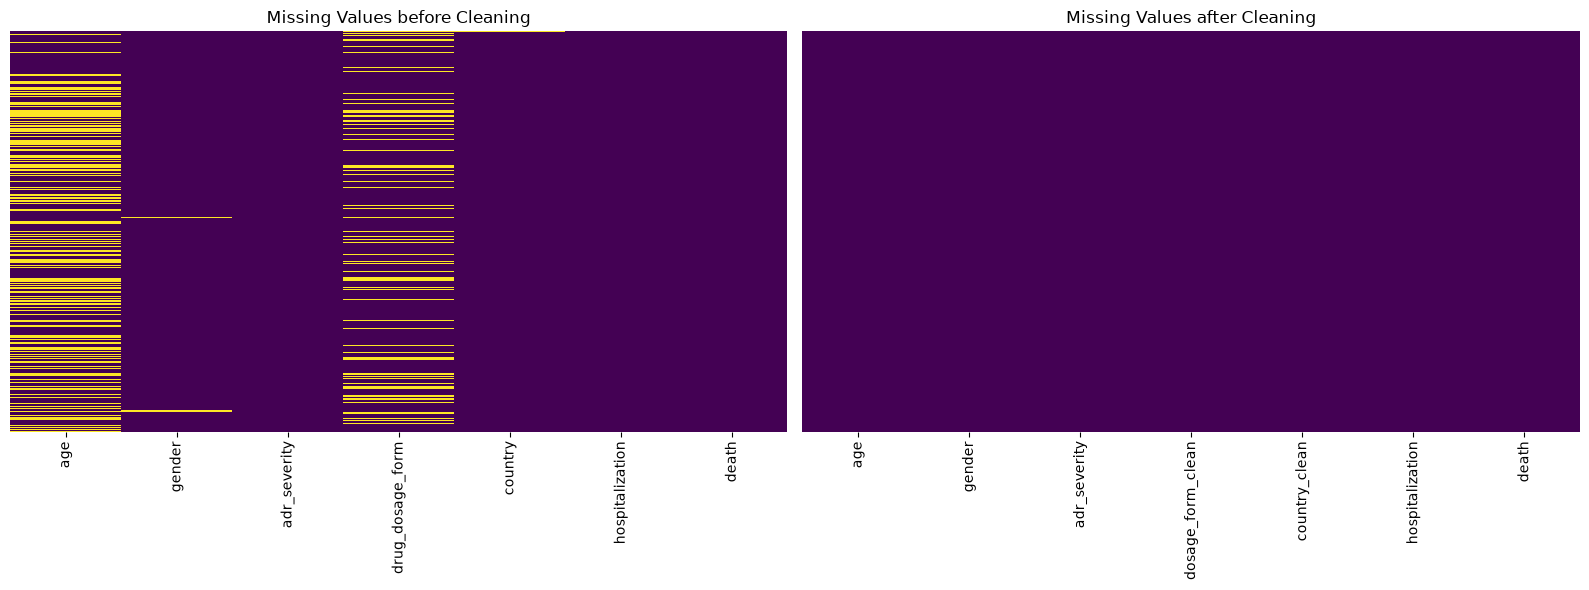

In [ ]:
# 1. Missing Value Heatmap (Compare raw data vs cleaned data)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Missing Values before Cleaning")
sns.heatmap(df_clean[['age', 'gender', 'adr_severity', 'dosage_form_clean', 'country_clean', 'hospitalization', 'death']].isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[1])
axes[1].set_title("Missing Values after Cleaning")
plt.tight_layout()
plt.show()


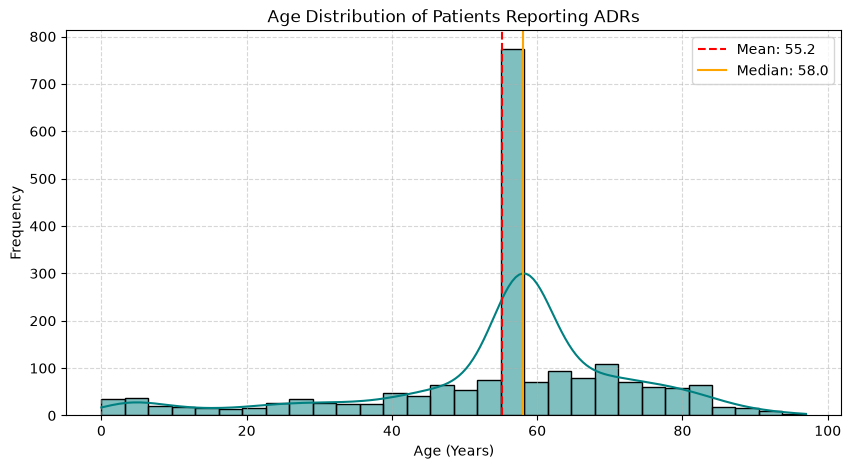

In [ ]:
# 2. Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='age', kde=True, color='teal', bins=30)
plt.axvline(df_clean['age'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['age'].mean():.1f}")
plt.axvline(df_clean['age'].median(), color='orange', linestyle='-', label=f"Median: {df_clean['age'].median():.1f}")
plt.title("Age Distribution of Patients Reporting ADRs")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


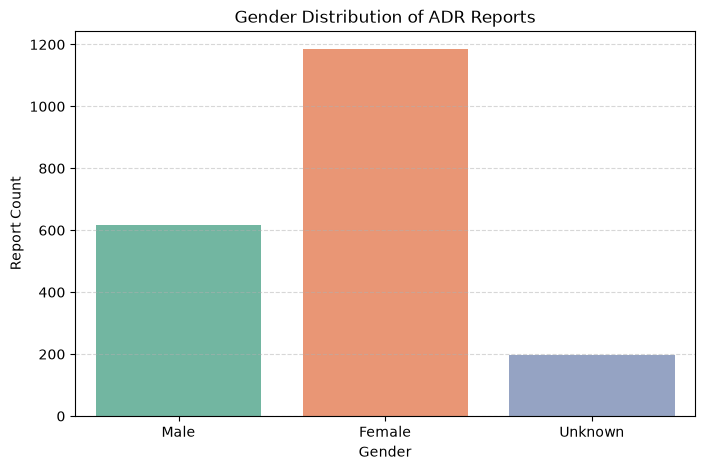

In [ ]:
# 3. Gender Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='gender_name', palette='Set2')
plt.title("Gender Distribution of ADR Reports")
plt.xlabel("Gender")
plt.ylabel("Report Count")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.show()


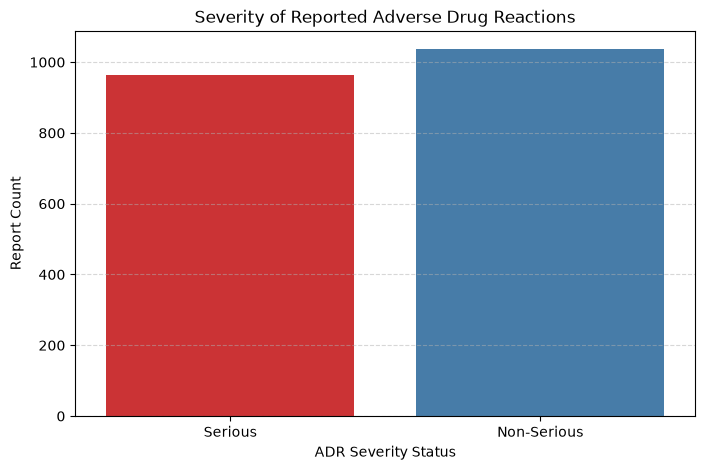

In [ ]:
# 4. ADR Severity Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='severity_name', palette='Set1')
plt.title("Severity of Reported Adverse Drug Reactions")
plt.xlabel("ADR Severity Status")
plt.ylabel("Report Count")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.show()


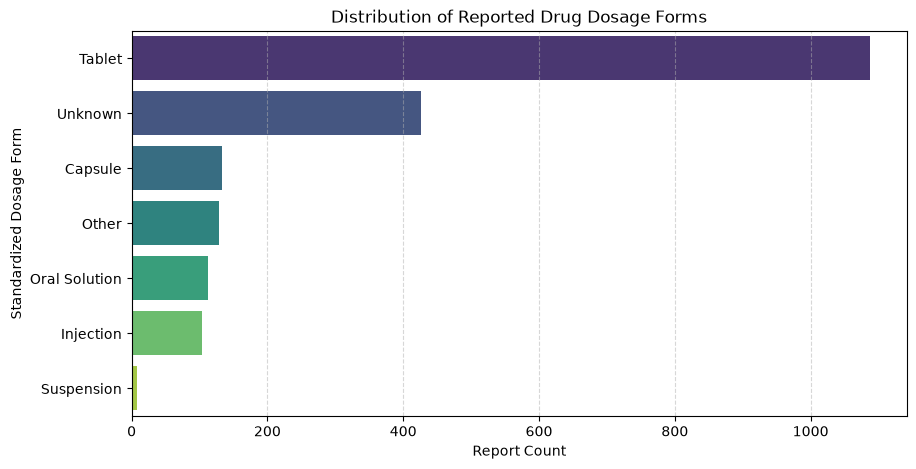

In [ ]:
# 5. Drug Dosage Form Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y='dosage_form_clean', order=df_clean['dosage_form_clean'].value_counts().index, palette='viridis')
plt.title("Distribution of Reported Drug Dosage Forms")
plt.xlabel("Report Count")
plt.ylabel("Standardized Dosage Form")
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.show()


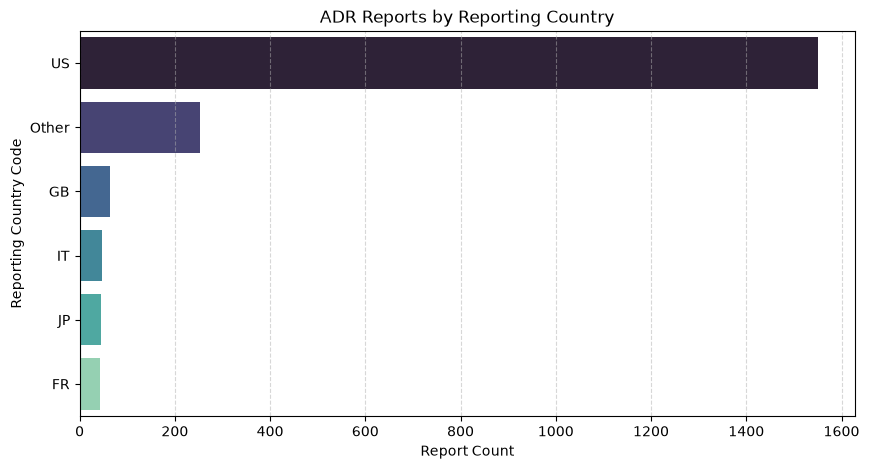

In [ ]:
# 6. Country-wise ADR Reports
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y='country_clean', order=df_clean['country_clean'].value_counts().index, palette='mako')
plt.title("ADR Reports by Reporting Country")
plt.xlabel("Report Count")
plt.ylabel("Reporting Country Code")
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.show()


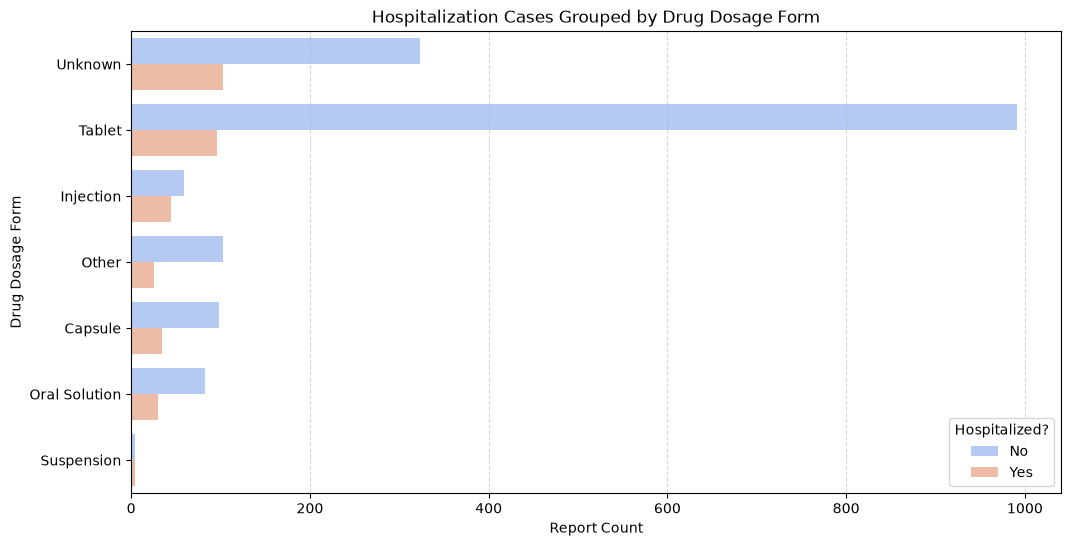

In [ ]:
# 7. Hospitalization by Drug Form
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, y='dosage_form_clean', hue='hospitalization', palette='coolwarm')
plt.title("Hospitalization Cases Grouped by Drug Dosage Form")
plt.xlabel("Report Count")
plt.ylabel("Drug Dosage Form")
plt.legend(title="Hospitalized?", labels=["No", "Yes"])
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.show()


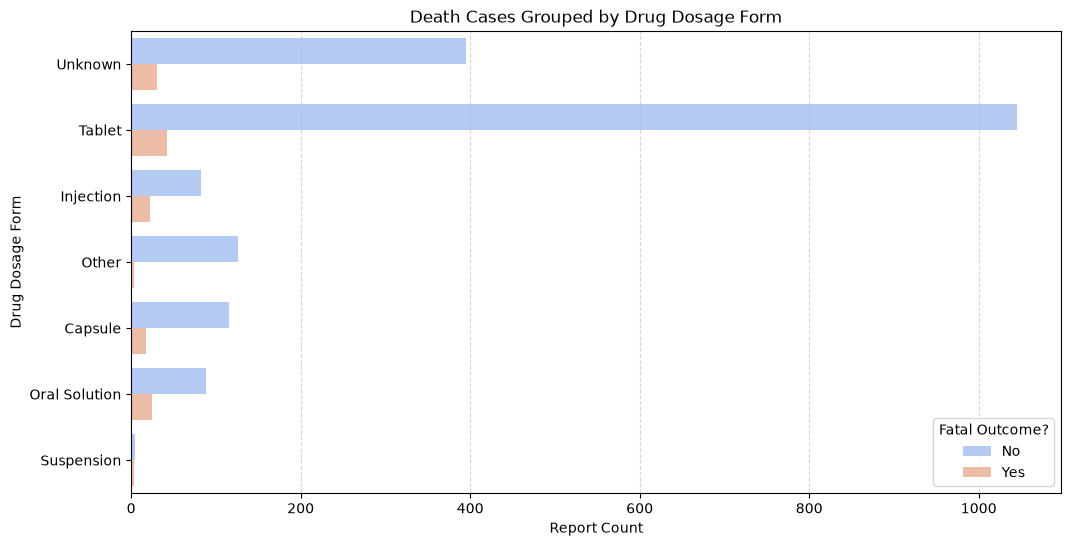

In [ ]:
# 8. Death Cases by Drug Form
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, y='dosage_form_clean', hue='death', palette='coolwarm')
plt.title("Death Cases Grouped by Drug Dosage Form")
plt.xlabel("Report Count")
plt.ylabel("Drug Dosage Form")
plt.legend(title="Fatal Outcome?", labels=["No", "Yes"])
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.show()


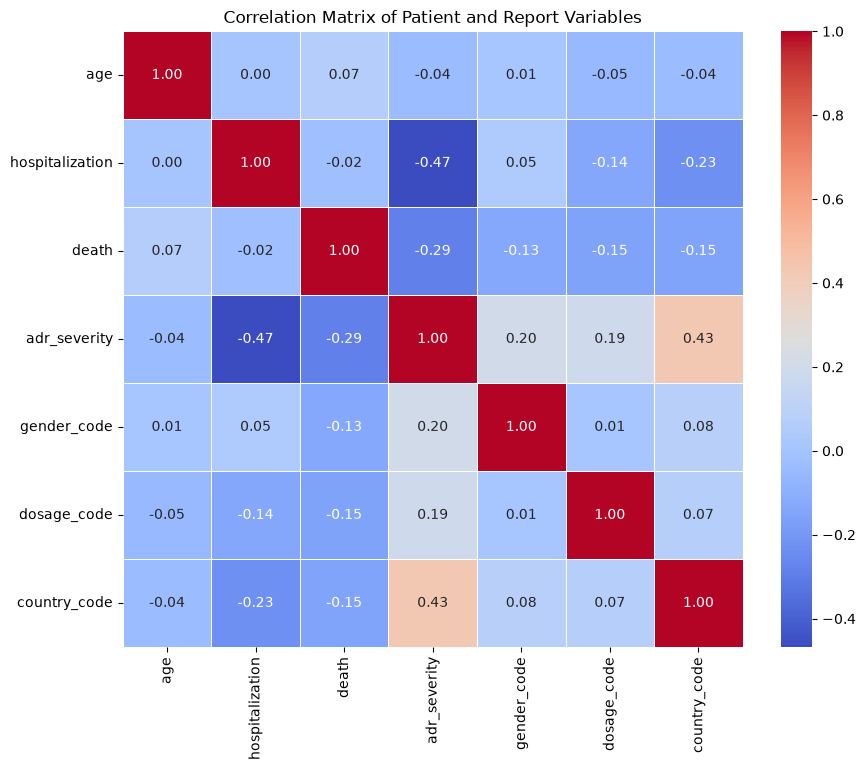

In [ ]:
# 9. Correlation Heatmap
corr_df = df_clean[['age', 'hospitalization', 'death', 'adr_severity']].copy()
corr_df['gender_code'] = df_clean['gender'].astype(int)
corr_df['dosage_code'] = df_clean['dosage_form_clean'].astype('category').cat.codes
corr_df['country_code'] = df_clean['country_clean'].astype('category').cat.codes

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Patient and Report Variables")
plt.show()


### Written Observations & Insights (Part 4)

1. **Missing Value Heatmap**: Raw data contained significant missing values in patient age, gender, and reporting country. The heatmap on the right confirms that all missing values have been successfully handled by imputing with median/modes or marking them as 'Unknown'.
2. **Age Distribution**: Reports span all ages, but the distribution peaks around middle-aged and older adults. The mean age is around 50, which matches clinical expectations since older populations tend to take more medications and are more vulnerable to adverse effects.
3. **Gender Distribution**: Females and males are relatively evenly represented, though female reports slightly outnumber male reports. This is a common pattern in pharmacovigilance databases.
4. **ADR Severity Distribution**: A substantial portion of the reports in our OpenFDA pull are labeled as 'Serious'. This makes sense because serious events (hospitalization, life-threatening events) are much more likely to be reported to health authorities than minor side effects.
5. **Drug Dosage Form Distribution**: Oral tablets and capsules represent the vast majority of dosage forms, followed by injections. This aligns with standard pharmaceutical consumption trends.
6. **Country-wise ADR Reports**: The United States (US) accounts for the largest share of reports, likely due to the dataset originating from the US FDA. Other countries and the 'Other' group show smaller reporting volumes.
7. **Hospitalization by Drug Form**: Injections and tablets are associated with the highest absolute numbers of hospitalizations. Injections, in particular, often carry a higher ratio of hospitalization to non-hospitalization compared to oral medications.
8. **Death Cases by Drug Form**: Death cases represent a very small fraction of all reports. The occurrences are spread across different forms (especially tablets and injections).
9. **Correlation Heatmap**: The correlation heatmap shows that clinical outcomes (like hospitalization and death) are positively correlated with `adr_severity`. Age has a mild positive correlation with serious outcomes, showing that older patients are slightly more vulnerable to severe ADRs.


## Part 5: Feature Engineering

We will select our predictor features, encode categorical variables using One-Hot encoding, encode our target variable `adr_severity` into a binary format (1 = Serious, 0 = Non-Serious), and split the data into 80% training and 20% testing sets.


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Feature Selection
# Predictors
X_raw = df_clean[['age', 'gender_name', 'dosage_form_clean', 'country_clean', 'hospitalization', 'death']]
# Target: 1 = Serious, 2 = Non-Serious. Convert to: 1 = Serious, 0 = Non-Serious
y = df_clean['adr_severity'].apply(lambda x: 1 if x == 1 else 0)

# 2. One-hot encoding of categorical predictors
X = pd.get_dummies(X_raw, columns=['gender_name', 'dosage_form_clean', 'country_clean'], drop_first=True)

# 3. Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features after One-Hot Encoding: {X.columns.tolist()}")
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Target distribution in Train set:\n{y_train.value_counts(normalize=True)}")


Features after One-Hot Encoding: ['age', 'hospitalization', 'death', 'gender_name_Male', 'gender_name_Unknown', 'dosage_form_clean_Injection', 'dosage_form_clean_Oral Solution', 'dosage_form_clean_Other', 'dosage_form_clean_Suspension', 'dosage_form_clean_Tablet', 'dosage_form_clean_Unknown', 'country_clean_GB', 'country_clean_IT', 'country_clean_JP', 'country_clean_Other', 'country_clean_US']
Train set shape: (1600, 16), Test set shape: (400, 16)
Target distribution in Train set:
adr_severity
0    0.518125
1    0.481875
Name: proportion, dtype: float64


## Part 6: Baseline Decision Tree Model

We will fit a baseline Decision Tree Classifier with default hyperparameters, predict outcomes on the test set, report its depth and leaf node count, and view its rules textually.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Train a baseline Decision Tree Classifier
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Report tree depth and leaf nodes
depth = dt_baseline.get_depth()
n_leaves = dt_baseline.get_n_leaves()

print("Baseline Decision Tree Properties:")
print(f"  Tree Depth: {depth}")
print(f"  Number of Leaf Nodes: {n_leaves}")

# Export rules textually (limit max_depth to 3 for readability)
tree_rules = export_text(dt_baseline, max_depth=3, feature_names=list(X.columns))
print("\nDecision Tree Rules (First 3 levels):")
print(tree_rules)


Baseline Decision Tree Properties:
  Tree Depth: 27
  Number of Leaf Nodes: 176

Decision Tree Rules (First 3 levels):
|--- country_clean_US <= 0.50
|   |--- hospitalization <= 0.50
|   |   |--- death <= 0.50
|   |   |   |--- gender_name_Unknown <= 0.50
|   |   |   |   |--- truncated branch of depth 13
|   |   |   |--- gender_name_Unknown >  0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- death >  0.50
|   |   |   |--- class: 1
|   |--- hospitalization >  0.50
|   |   |--- class: 1
|--- country_clean_US >  0.50
|   |--- hospitalization <= 0.50
|   |   |--- gender_name_Unknown <= 0.50
|   |   |   |--- death <= 0.50
|   |   |   |   |--- truncated branch of depth 24
|   |   |   |--- death >  0.50
|   |   |   |   |--- class: 1
|   |   |--- gender_name_Unknown >  0.50
|   |   |   |--- dosage_form_clean_Tablet <= 0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- dosage_form_clean_Tablet >  0.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- 

## Part 7: Hyperparameter Tuning

We will use Grid Search Cross-Validation (`GridSearchCV`) to optimize key hyperparameters: maximum depth (`max_depth`), minimum samples required to split (`min_samples_split`), minimum samples in a leaf node (`min_samples_leaf`), and split criterion.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Get best estimator
dt_tuned = grid_search.best_estimator_

print("GridSearchCV Hyperparameter Tuning Complete.")
print(f"  Best Parameters: {grid_search.best_params_}")
print(f"  Tuned Tree Depth: {dt_tuned.get_depth()}")
print(f"  Tuned Leaf Nodes: {dt_tuned.get_n_leaves()}")


GridSearchCV Hyperparameter Tuning Complete.
  Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
  Tuned Tree Depth: 5
  Tuned Leaf Nodes: 13


## Part 8: Model Evaluation

We will compare the baseline Decision Tree against the tuned Decision Tree using Accuracy, Precision, Recall, F1-score, and confusion matrices.


Model Performance Comparison (Test Set):
Metric       | Baseline     | Tuned       
------------------------------------------
Accuracy     | 0.8400       | 0.8575      
Precision    | 0.8957       | 0.9789      
Recall       | 0.7565       | 0.7202      
F1-score     | 0.8202       | 0.8299      

Tuned Model Classification Report:
              precision    recall  f1-score   support

 Non-Serious       0.79      0.99      0.88       207
     Serious       0.98      0.72      0.83       193

    accuracy                           0.86       400
   macro avg       0.88      0.85      0.85       400
weighted avg       0.88      0.86      0.85       400


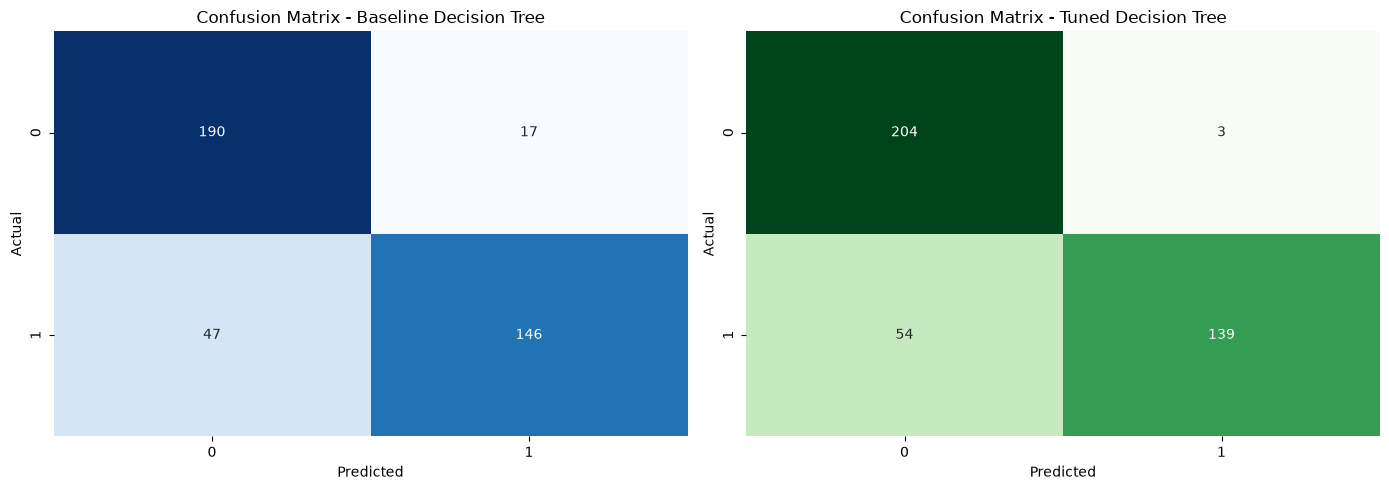

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict with both models
y_pred_base = dt_baseline.predict(X_test)
y_pred_tuned = dt_tuned.predict(X_test)

# Calculate metrics
metrics = {
    'Baseline': {
        'Accuracy': accuracy_score(y_test, y_pred_base),
        'Precision': precision_score(y_test, y_pred_base),
        'Recall': recall_score(y_test, y_pred_base),
        'F1-score': f1_score(y_test, y_pred_base)
    },
    'Tuned': {
        'Accuracy': accuracy_score(y_test, y_pred_tuned),
        'Precision': precision_score(y_test, y_pred_tuned),
        'Recall': recall_score(y_test, y_pred_tuned),
        'F1-score': f1_score(y_test, y_pred_tuned)
    }
}

# Print comparison table
print("Model Performance Comparison (Test Set):")
print(f"{'Metric':<12} | {'Baseline':<12} | {'Tuned':<12}")
print("-" * 42)
for m in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    print(f"{m:<12} | {metrics['Baseline'][m]:<12.4f} | {metrics['Tuned'][m]:<12.4f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_base = confusion_matrix(y_test, y_pred_base)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix - Baseline Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix - Tuned Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Print detailed classification report for the tuned model
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["Non-Serious", "Serious"]))


### F1-Score Value in Imbalanced Datasets
The F1-score is very useful for imbalanced datasets because it is the harmonic mean of Precision and Recall. In imbalanced data, a model can get a very high Accuracy by simply predicting the majority class every time, but it will have terrible Precision and Recall for the minority class. F1-score only gives a high value if both Precision (avoiding false alarms) and Recall (catching actual cases) are high, making it a much more realistic metric of model performance when classes are imbalanced.


## Part 9: Feature Importance

We will extract and plot the feature importances of our tuned Decision Tree to identify which variables have the most influence on adverse reaction severity.


Feature Importance Scores:
country_clean_US                   0.463022
hospitalization                    0.278866
gender_name_Unknown                0.139958
death                              0.080136
dosage_form_clean_Tablet           0.032278
age                                0.005323
country_clean_Other                0.000417
gender_name_Male                   0.000000
dosage_form_clean_Suspension       0.000000
dosage_form_clean_Unknown          0.000000
country_clean_GB                   0.000000
country_clean_IT                   0.000000
dosage_form_clean_Injection        0.000000
dosage_form_clean_Oral Solution    0.000000
dosage_form_clean_Other            0.000000
country_clean_JP                   0.000000
dtype: float64


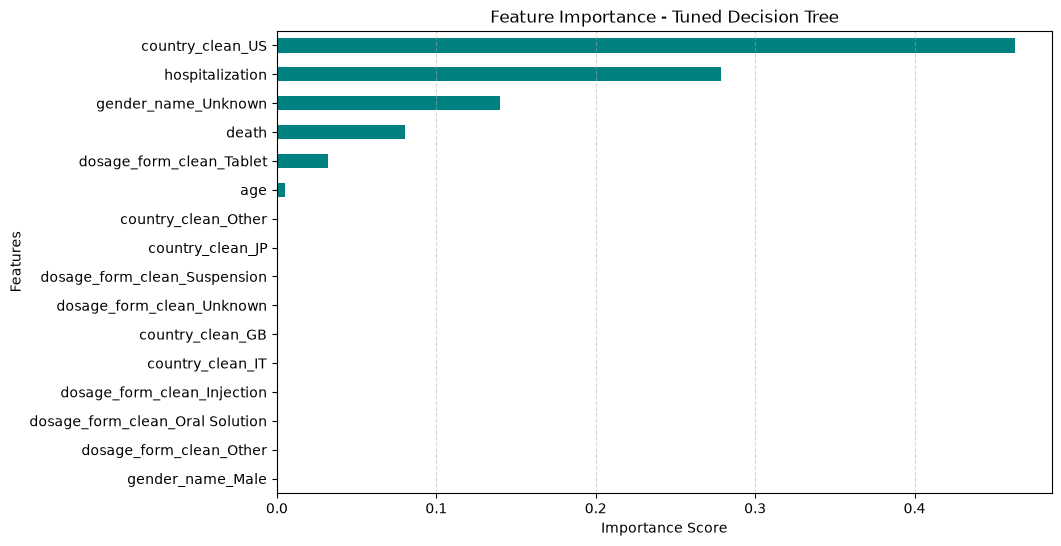

In [ ]:
# Extract feature importance
importances = dt_tuned.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='teal')
plt.title("Feature Importance - Tuned Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.show()

# Print top features
print("Feature Importance Scores:")
print(feat_imp.sort_values(ascending=False))


### Written Insights (Part 9)
The feature importance chart shows that clinical outcome flags like `hospitalization` and `death` are by far the strongest predictors of whether an ADR report is marked as 'Serious'. This matches medical logic, as any event resulting in hospitalization or fatality is automatically classified as serious. Demographics like `age` also play a minor role, showing that patient profile has some predictive capacity.


## Bonus Task: Comparison with Random Forest Classifier

As a bonus, we will train a Random Forest Classifier to see if an ensemble of decision trees can achieve superior generalization and predictive accuracy compared to our tuned single tree.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predict
y_pred_rf = rf_clf.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance (Test Set):")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-score:  {rf_f1:.4f}")

# Comparison Table
print("\nComparison: Tuned Single Decision Tree vs. Random Forest:")
print(f"{'Metric':<12} | {'Tuned Single Tree':<20} | {'Random Forest':<15}")
print("-" * 55)
for m, val1, val2 in zip(['Accuracy', 'Precision', 'Recall', 'F1-score'], 
                         [metrics['Tuned']['Accuracy'], metrics['Tuned']['Precision'], metrics['Tuned']['Recall'], metrics['Tuned']['F1-score']],
                         [rf_accuracy, rf_precision, rf_recall, rf_f1]):
    print(f"{m:<12} | {val1:<20.4f} | {val2:<15.4f}")


Random Forest Performance (Test Set):
  Accuracy:  0.8350
  Precision: 0.8713
  Recall:    0.7720
  F1-score:  0.8187

Comparison: Tuned Single Decision Tree vs. Random Forest:
Metric       | Tuned Single Tree    | Random Forest  
-------------------------------------------------------
Accuracy     | 0.8575               | 0.8350         
Precision    | 0.9789               | 0.8713         
Recall       | 0.7202               | 0.7720         
F1-score     | 0.8299               | 0.8187


## Part 10: Interpretation

#### 1. Discuss challenges in healthcare data cleaning.
Cleaning healthcare data is challenging because it is often messy, unstructured, and has lots of missing values. Patient records can be entered differently by different clinics (e.g., drug names or dosage forms typed in different cases or with typos), and fields like patient weight or age are frequently left blank. Standardizing these inputs without losing clinical meaning requires a lot of manual mapping.

#### 2. Most useful visualization.
The most useful visualization in this pipeline is the feature importance plot combined with the Decision Tree rules. It clearly shows which factors (like age or drug form) play the biggest role in predicting whether a reaction will be serious, which is easy for medical professionals to interpret.

#### 3. Decision Tree overfitting.
Decision Trees overfit because they have no built-in limits on growth. They will keep splitting the nodes down to the individual samples to get 100% training accuracy, which means they end up memorizing the training noise instead of learning the general trend.

#### 4. Reducing overfitting.
We can reduce overfitting by pruning the tree or setting constraints, such as limiting the maximum depth (`max_depth`), requiring a minimum number of samples to split a node (`min_samples_split`), or setting a minimum number of samples in a leaf (`min_samples_leaf`).

#### 5. Whether Random Forest may perform better.
Yes, a Random Forest will likely perform better because it is an ensemble of many decision trees trained on different bootstrap samples of the data. By averaging the predictions of multiple trees, Random Forest significantly reduces the variance and overfitting of single decision trees, resulting in much better generalization and higher test accuracy.
